In [1]:

# Complete restart with highly optimized vectorized approach
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit, minimize
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Optimized implementation for tail-lightness vs R_comp correlation analysis")
print("=" * 75)

# PARAMETERS - adjusted for computational feasibility
N = 10000 # Using 10^4 as recommended in dataset description for pilot studies
n_samples = 300 # Reduced but still sufficient for statistical analysis
alpha_values = np.arange(0.0, 1.1, 0.1)
t_min, t_max = 1000, 5000

print(f"\nParameters (adjusted for computational feasibility):")
print(f" N = {N:,} (pilot study at smaller N per r6 strategy)")
print(f" α values: {len(alpha_values)} points from 0.0 to 1.0")
print(f" Samples per α: {n_samples}")
print(f" t range: [{t_min}, {t_max}]")


Optimized implementation for tail-lightness vs R_comp correlation analysis

Parameters (adjusted for computational feasibility):
 N = 10,000 (pilot study at smaller N per r6 strategy)
 α values: 11 points from 0.0 to 1.0
 Samples per α: 300
 t range: [1000, 5000]


In [2]:

# Highly optimized vectorized implementation
def compute_primes_sieve(n_max):
 """Sieve of Eratosthenes"""
 if n_max < 2:
 return np.array([], dtype=np.int64)
 sieve = np.ones(n_max + 1, dtype=bool)
 sieve[0:2] = False
 for i in range(2, int(np.sqrt(n_max)) + 1):
 if sieve[i]:
 sieve[i*i::i] = False
 return np.where(sieve)[0]

def generate_mult_coeffs_fast(N, alpha, primes, seed=None):
 """Fast multiplicative coefficient generation"""
 if seed is not None:
 np.random.seed(seed)
 
 a = np.ones(N + 1, dtype=np.float64)
 
 # Set prime values
 for p in primes:
 if p <= N:
 a[p] = 1.0 if np.random.rand() < alpha else -1.0
 
 # Multiplicative extension - optimized
 for p in primes:
 if p > N:
 break
 power = p
 while power <= N:
 a[power::power] *= a[p]
 power *= p
 
 return a

def compute_D_F_vectorized(t, N, a):
 """Vectorized D_F computation"""
 n = np.arange(1, N + 1)
 log_n = np.log(n)
 
 # n^(-1/2-it) = exp(-0.5*log(n) - it*log(n))
 real_exp = np.exp(-0.5 * log_n)
 phases = -t * log_n
 
 # Complex sum with coefficient
 terms = a[1:] * real_exp * (np.cos(phases) + 1j * np.sin(phases))
 
 # Standard sum (Kahan would be better but too slow for this scale)
 D_F = np.sum(terms)
 return np.abs(D_F)

def compute_R_comp_fast(t, N, a, prime_set):
 """Fast R_comp using precomputed omega values"""
 # Precompute squarefree composites with omega >= 2
 composite_mask = np.zeros(N + 1, dtype=bool)
 
 for n in range(2, N + 1):
 # Quick omega count and squarefree check
 temp = n
 omega = 0
 is_sf = True
 
 for p in prime_set:
 if p * p > temp:
 if temp > 1:
 omega += 1
 break
 cnt = 0
 while temp % p == 0:
 temp //= p
 cnt += 1
 if cnt > 1:
 is_sf = False
 break
 if cnt == 1:
 omega += 1
 
 if is_sf and omega >= 2:
 composite_mask[n] = True
 
 # Compute phases for selected terms
 comp_indices = np.where(composite_mask)[0]
 if len(comp_indices) == 0:
 return 0.0
 
 phases = np.where(a[comp_indices] > 0, 0, np.pi) - t * np.log(comp_indices)
 unit_vecs = np.exp(1j * phases)
 return np.abs(np.mean(unit_vecs))

print("Optimized functions defined")
print("Computing primes...")
primes = compute_primes_sieve(N)
prime_set = set(primes)
print(f"Found {len(primes):,} primes")

# Generate t values
np.random.seed(42)
t_values = np.random.uniform(t_min, t_max, n_samples)
print(f"Generated {n_samples} t values\n")


Optimized functions defined
Computing primes...
Found 1,229 primes
Generated 300 t values



In [3]:

# Generate data - this should be much faster now
from tqdm import tqdm

results = {}

print("Generating data for each α value...")
print("(This will take a few minutes)\n")

for idx, alpha in enumerate(alpha_values):
 print(f"Processing α = {alpha:.1f} ({idx+1}/{len(alpha_values)})...")
 
 # Generate coefficients
 seed = int(alpha * 100) + 1000
 a = generate_mult_coeffs_fast(N, alpha, primes, seed=seed)
 
 # Compute D_F and R_comp for all t values
 D_F_vals = []
 R_comp_vals = []
 
 for t in t_values:
 D_F = compute_D_F_vectorized(t, N, a)
 R_comp = compute_R_comp_fast(t, N, a, prime_set)
 D_F_vals.append(D_F)
 R_comp_vals.append(R_comp)
 
 results[alpha] = {
 'D_F': np.array(D_F_vals),
 'R_comp': np.array(R_comp_vals),
 'mean_R_comp': np.mean(R_comp_vals),
 'std_R_comp': np.std(R_comp_vals)
 }
 
 print(f" Mean R_comp = {results[alpha]['mean_R_comp']:.6f}")
 print(f" Mean |D_F| = {np.mean(D_F_vals):.4f}\n")

print("Data generation complete!\n")
print("=" * 75)


Generating data for each α value...
(This will take a few minutes)

Processing α = 0.0 (1/11)...


 Mean R_comp = 0.011774
 Mean |D_F| = 2.8635

Processing α = 0.1 (2/11)...


 Mean R_comp = 0.012158
 Mean |D_F| = 2.8822

Processing α = 0.2 (3/11)...


 Mean R_comp = 0.012220
 Mean |D_F| = 2.6653

Processing α = 0.3 (4/11)...


 Mean R_comp = 0.011893
 Mean |D_F| = 2.7442

Processing α = 0.4 (5/11)...


...

 Mean R_comp = 0.013086
 Mean |D_F| = 2.4039

Processing α = 0.7 (8/11)...


 Mean R_comp = 0.013479
 Mean |D_F| = 2.6593

Processing α = 0.8 (9/11)...


 Mean R_comp = 0.011895
 Mean |D_F| = 2.2727

Processing α = 0.9 (10/11)...


 Mean R_comp = 0.011474
 Mean |D_F| = 2.1278

Processing α = 1.0 (11/11)...


 Mean R_comp = 0.010022
 Mean |D_F| = 1.8624

Data generation complete!



In [4]:

# Now fit power law and stretched exponential to the upper tail (top 10%)
# Power law: P(X > x) ~ x^(-k) => log P(X > x) ~ -k log(x)
# Stretched exponential: P(X > x) ~ exp(-c * x^β) => log P(X > x) ~ -c * x^β

def fit_power_law_tail(data, percentile=90):
 """
 Fit power law to upper tail using survival function.
 Returns: fitted parameters, AIC, BIC
 """
 threshold = np.percentile(data, percentile)
 tail_data = data[data >= threshold]
 
 if len(tail_data) < 10:
 return None, np.inf, np.inf
 
 # Sort tail data
 x = np.sort(tail_data)
 n = len(x)
 
 # Empirical survival function
 sf = 1 - np.arange(1, n + 1) / n
 
 # Remove zeros for log
 mask = (sf > 0) & (x > 0)
 x_fit = x[mask]
 sf_fit = sf[mask]
 
 if len(x_fit) < 5:
 return None, np.inf, np.inf
 
 # Fit: log(SF) = log(C) - k*log(x)
 try:
 # Use only points where SF > 0.01 for stability
 mask2 = sf_fit > 0.01
 if mask2.sum() < 5:
 mask2 = np.ones(len(sf_fit), dtype=bool)
 
 log_x = np.log(x_fit[mask2])
 log_sf = np.log(sf_fit[mask2])
 
 # Linear regression
 coeffs = np.polyfit(log_x, log_sf, 1)
 k = -coeffs[0] # Power law exponent
 log_C = coeffs[1]
 
 # Predict and compute likelihood
 log_sf_pred = log_C - k * np.log(x_fit)
 residuals = log_sf - log_sf_pred[:len(log_sf)]
 
 # Compute log-likelihood (assuming Gaussian errors on log scale)
 sigma = np.std(residuals)
 if sigma == 0:
 sigma = 1e-10
 log_lik = -0.5 * n * np.log(2 * np.pi * sigma**2) - 0.5 * np.sum(residuals**2) / sigma**2
 
 # AIC and BIC
 num_params = 2 # k and C
 AIC = 2 * num_params - 2 * log_lik
 BIC = num_params * np.log(n) - 2 * log_lik
 
 params = {'k': k, 'C': np.exp(log_C)}
 return params, AIC, BIC
 except:
 return None, np.inf, np.inf

def fit_stretched_exp_tail(data, percentile=90):
 """
 Fit stretched exponential to upper tail.
 Returns: fitted parameters, AIC, BIC
 """
 threshold = np.percentile(data, percentile)
 tail_data = data[data >= threshold]
 
 if len(tail_data) < 10:
 return None, np.inf, np.inf
 
 x = np.sort(tail_data)
 n = len(x)
 
 sf = 1 - np.arange(1, n + 1) / n
 mask = (sf > 0) & (x > 0)
 x_fit = x[mask]
 sf_fit = sf[mask]
 
 if len(x_fit) < 5:
 return None, np.inf, np.inf
 
 # Fit: log(SF) = -c * x^β
 try:
 # Use only points where SF > 0.01
 mask2 = sf_fit > 0.01
 if mask2.sum() < 5:
 mask2 = np.ones(len(sf_fit), dtype=bool)
 
 x_data = x_fit[mask2]
 log_sf_data = np.log(sf_fit[mask2])
 
 # Nonlinear least squares
 def objective(params):
 c, beta = params
 if c <= 0 or beta <= 0:
 return 1e10
 pred = -c * x_data**beta
 return np.sum((log_sf_data - pred)**2)
 
 # Initial guess
 from scipy.optimize import minimize
 res = minimize(objective, x0=[0.01, 0.5], method='Nelder-Mead',
 bounds=[(1e-6, 10), (0.1, 2)])
 
 if not res.success:
 return None, np.inf, np.inf
 
 c, beta = res.x
 
 # Compute likelihood
 log_sf_pred = -c * x_fit**beta
 residuals = log_sf_data - log_sf_pred[:len(log_sf_data)]
 sigma = np.std(residuals)
 if sigma == 0:
 sigma = 1e-10
 log_lik = -0.5 * n * np.log(2 * np.pi * sigma**2) - 0.5 * np.sum(residuals**2) / sigma**2
 
 num_params = 2 # c and beta
 AIC = 2 * num_params - 2 * log_lik
 BIC = num_params * np.log(n) - 2 * log_lik
 
 params = {'c': c, 'beta': beta}
 return params, AIC, BIC
 except:
 return None, np.inf, np.inf

print("Tail fitting functions defined")
print("Fitting models to each α...\n")


Tail fitting functions defined
Fitting models to each α...



In [5]:

# Fit models for each α
model_results = {}

for alpha in alpha_values:
 D_F_data = results[alpha]['D_F']
 
 # Fit power law
 pl_params, pl_AIC, pl_BIC = fit_power_law_tail(D_F_data, percentile=90)
 
 # Fit stretched exponential
 se_params, se_AIC, se_BIC = fit_stretched_exp_tail(D_F_data, percentile=90)
 
 # Determine preferred model (lower AIC is better)
 if pl_AIC < se_AIC:
 preferred = 'power_law'
 delta_AIC = se_AIC - pl_AIC
 else:
 preferred = 'stretched_exp'
 delta_AIC = pl_AIC - se_AIC
 
 model_results[alpha] = {
 'power_law': {'params': pl_params, 'AIC': pl_AIC, 'BIC': pl_BIC},
 'stretched_exp': {'params': se_params, 'AIC': se_AIC, 'BIC': se_BIC},
 'preferred': preferred,
 'delta_AIC': delta_AIC
 }
 
 print(f"α = {alpha:.1f}:")
 print(f" Power Law: AIC = {pl_AIC:.2f}, params = {pl_params}")
 print(f" Stretched Exp: AIC = {se_AIC:.2f}, params = {se_params}")
 print(f" Preferred: {preferred} (ΔAIC = {delta_AIC:.2f})")
 print()

print("Model fitting complete!")


α = 0.0:
 Power Law: AIC = -6.41, params = {'k': 4.8702165240404, 'C': 1856.6058230208066}
 Stretched Exp: AIC = 40.89, params = {'c': 0.031105167537927546, 'beta': 2.0}
 Preferred: power_law (ΔAIC = 47.29)

α = 0.1:
 Power Law: AIC = -23.89, params = {'k': 6.398004674491772, 'C': 36120.77782143696}
 Stretched Exp: AIC = 51.90, params = {'c': 0.02944381713867203, 'beta': 2.0}
 Preferred: power_law (ΔAIC = 75.79)

α = 0.2:
 Power Law: AIC = -28.94, params = {'k': 6.400806976775385, 'C': 17153.922573350268}
 Stretched Exp: AIC = 50.78, params = {'c': 0.03712614060860471, 'beta': 2.0}
 Preferred: power_law (ΔAIC = 79.72)

α = 0.3:
 Power Law: AIC = -25.23, params = {'k': 5.952738862702002, 'C': 12557.7018693557}
 Stretched Exp: AIC = 49.31, params = {'c': 0.03204498481750506, 'beta': 2.0}
 Preferred: power_law (ΔAIC = 74.54)

α = 0.4:
 Power Law: AIC = -11.42, params = {'k': 6.765955663091211, 'C': 57004.119486750606}
 Stretched Exp: AIC = 55.00, params = {'c': 0.0312713317871095, 'beta':

In [6]:

# Create summary DataFrame
summary_data = []

for alpha in alpha_values:
 summary_data.append({
 'alpha': alpha,
 'mean_R_comp': results[alpha]['mean_R_comp'],
 'std_R_comp': results[alpha]['std_R_comp'],
 'preferred_model': model_results[alpha]['preferred'],
 'delta_AIC': model_results[alpha]['delta_AIC'],
 'pl_AIC': model_results[alpha]['power_law']['AIC'],
 'se_AIC': model_results[alpha]['stretched_exp']['AIC']
 })

df_summary = pd.DataFrame(summary_data)

print("SUMMARY TABLE:")
print("=" * 80)
print(df_summary.to_string(index=False))
print("=" * 80)

# Count preferred models
n_power_law = (df_summary['preferred_model'] == 'power_law').sum()
n_stretched_exp = (df_summary['preferred_model'] == 'stretched_exp').sum()

print(f"\nModel preferences:")
print(f" Power law preferred: {n_power_law}/{len(alpha_values)}")
print(f" Stretched exponential preferred: {n_stretched_exp}/{len(alpha_values)}")


SUMMARY TABLE:
 alpha mean_R_comp std_R_comp preferred_model delta_AIC pl_AIC se_AIC
 0.0 0.011774 0.009268 power_law 47.292687 -6.405483 40.887204
 0.1 0.012158 0.008364 power_law 75.789022 -23.892604 51.896417
 0.2 0.012220 0.007552 power_law 79.722973 -28.944440 50.778532
 0.3 0.011893 0.007546 power_law 74.538788 -25.231110 49.307678
 0.4 0.011631 0.009091 power_law 66.422737 -11.422761 54.999976
 0.5 0.011545 0.007348 power_law 50.303166 -17.568385 32.734782
 0.6 0.013086 0.010515 power_law 21.137753 -22.327470 -1.189717
 0.7 0.013479 0.011422 stretched_exp 2.074894 -14.983152 -17.058046
 0.8 0.011895 0.008607 power_law 21.240641 -2.167727 19.072914
 0.9 0.011474 0.007567 stretched_exp 0.068306 12.421507 12.353201
 1.0 0.010022 0.005785 power_law 12.455004 -10.249163 2.205842

Model preferences:
 Power law preferred: 9/11
 Stretched exponential preferred: 2/11


In [7]:

# Analyze the correlation between R_comp and preferred model

# Look at the relationship between R_comp and model preference
print("CORRELATION ANALYSIS:")
print("=" * 80)

# Separate by model type
pl_alphas = df_summary[df_summary['preferred_model'] == 'power_law']['alpha'].values
se_alphas = df_summary[df_summary['preferred_model'] == 'stretched_exp']['alpha'].values

pl_R_comps = df_summary[df_summary['preferred_model'] == 'power_law']['mean_R_comp'].values
se_R_comps = df_summary[df_summary['preferred_model'] == 'stretched_exp']['mean_R_comp'].values

print(f"\nPower law preferred at α = {pl_alphas}")
print(f" Mean R_comp = {np.mean(pl_R_comps):.6f} ± {np.std(pl_R_comps):.6f}")

print(f"\nStretched exponential preferred at α = {se_alphas}")
print(f" Mean R_comp = {np.mean(se_R_comps):.6f} ± {np.std(se_R_comps):.6f}")

# Statistical test
if len(se_R_comps) >= 2 and len(pl_R_comps) >= 2:
 from scipy import stats as sp_stats
 t_stat, p_val = sp_stats.ttest_ind(pl_R_comps, se_R_comps)
 print(f"\nTwo-sample t-test:")
 print(f" t-statistic = {t_stat:.4f}")
 print(f" p-value = {p_val:.4f}")
 if p_val < 0.05:
 print(f" Result: Significant difference (p < 0.05)")
 else:
 print(f" Result: No significant difference (p >= 0.05)")

# Check correlation between R_comp and α
corr_R_alpha = np.corrcoef(df_summary['alpha'], df_summary['mean_R_comp'])[0, 1]
print(f"\nCorrelation between α and mean R_comp: {corr_R_alpha:.4f}")

print("\n" + "=" * 80)


CORRELATION ANALYSIS:

Power law preferred at α = [0. 0.1 0.2 0.3 0.4 0.5 0.6 0.8 1. ]
 Mean R_comp = 0.011803 ± 0.000762

Stretched exponential preferred at α = [0.7 0.9]
 Mean R_comp = 0.012477 ± 0.001002

Two-sample t-test:
 t-statistic = -0.9610
 p-value = 0.3616
 Result: No significant difference (p >= 0.05)

Correlation between α and mean R_comp: -0.2647



Figure saved as 'tail_lightness_vs_Rcomp.png'


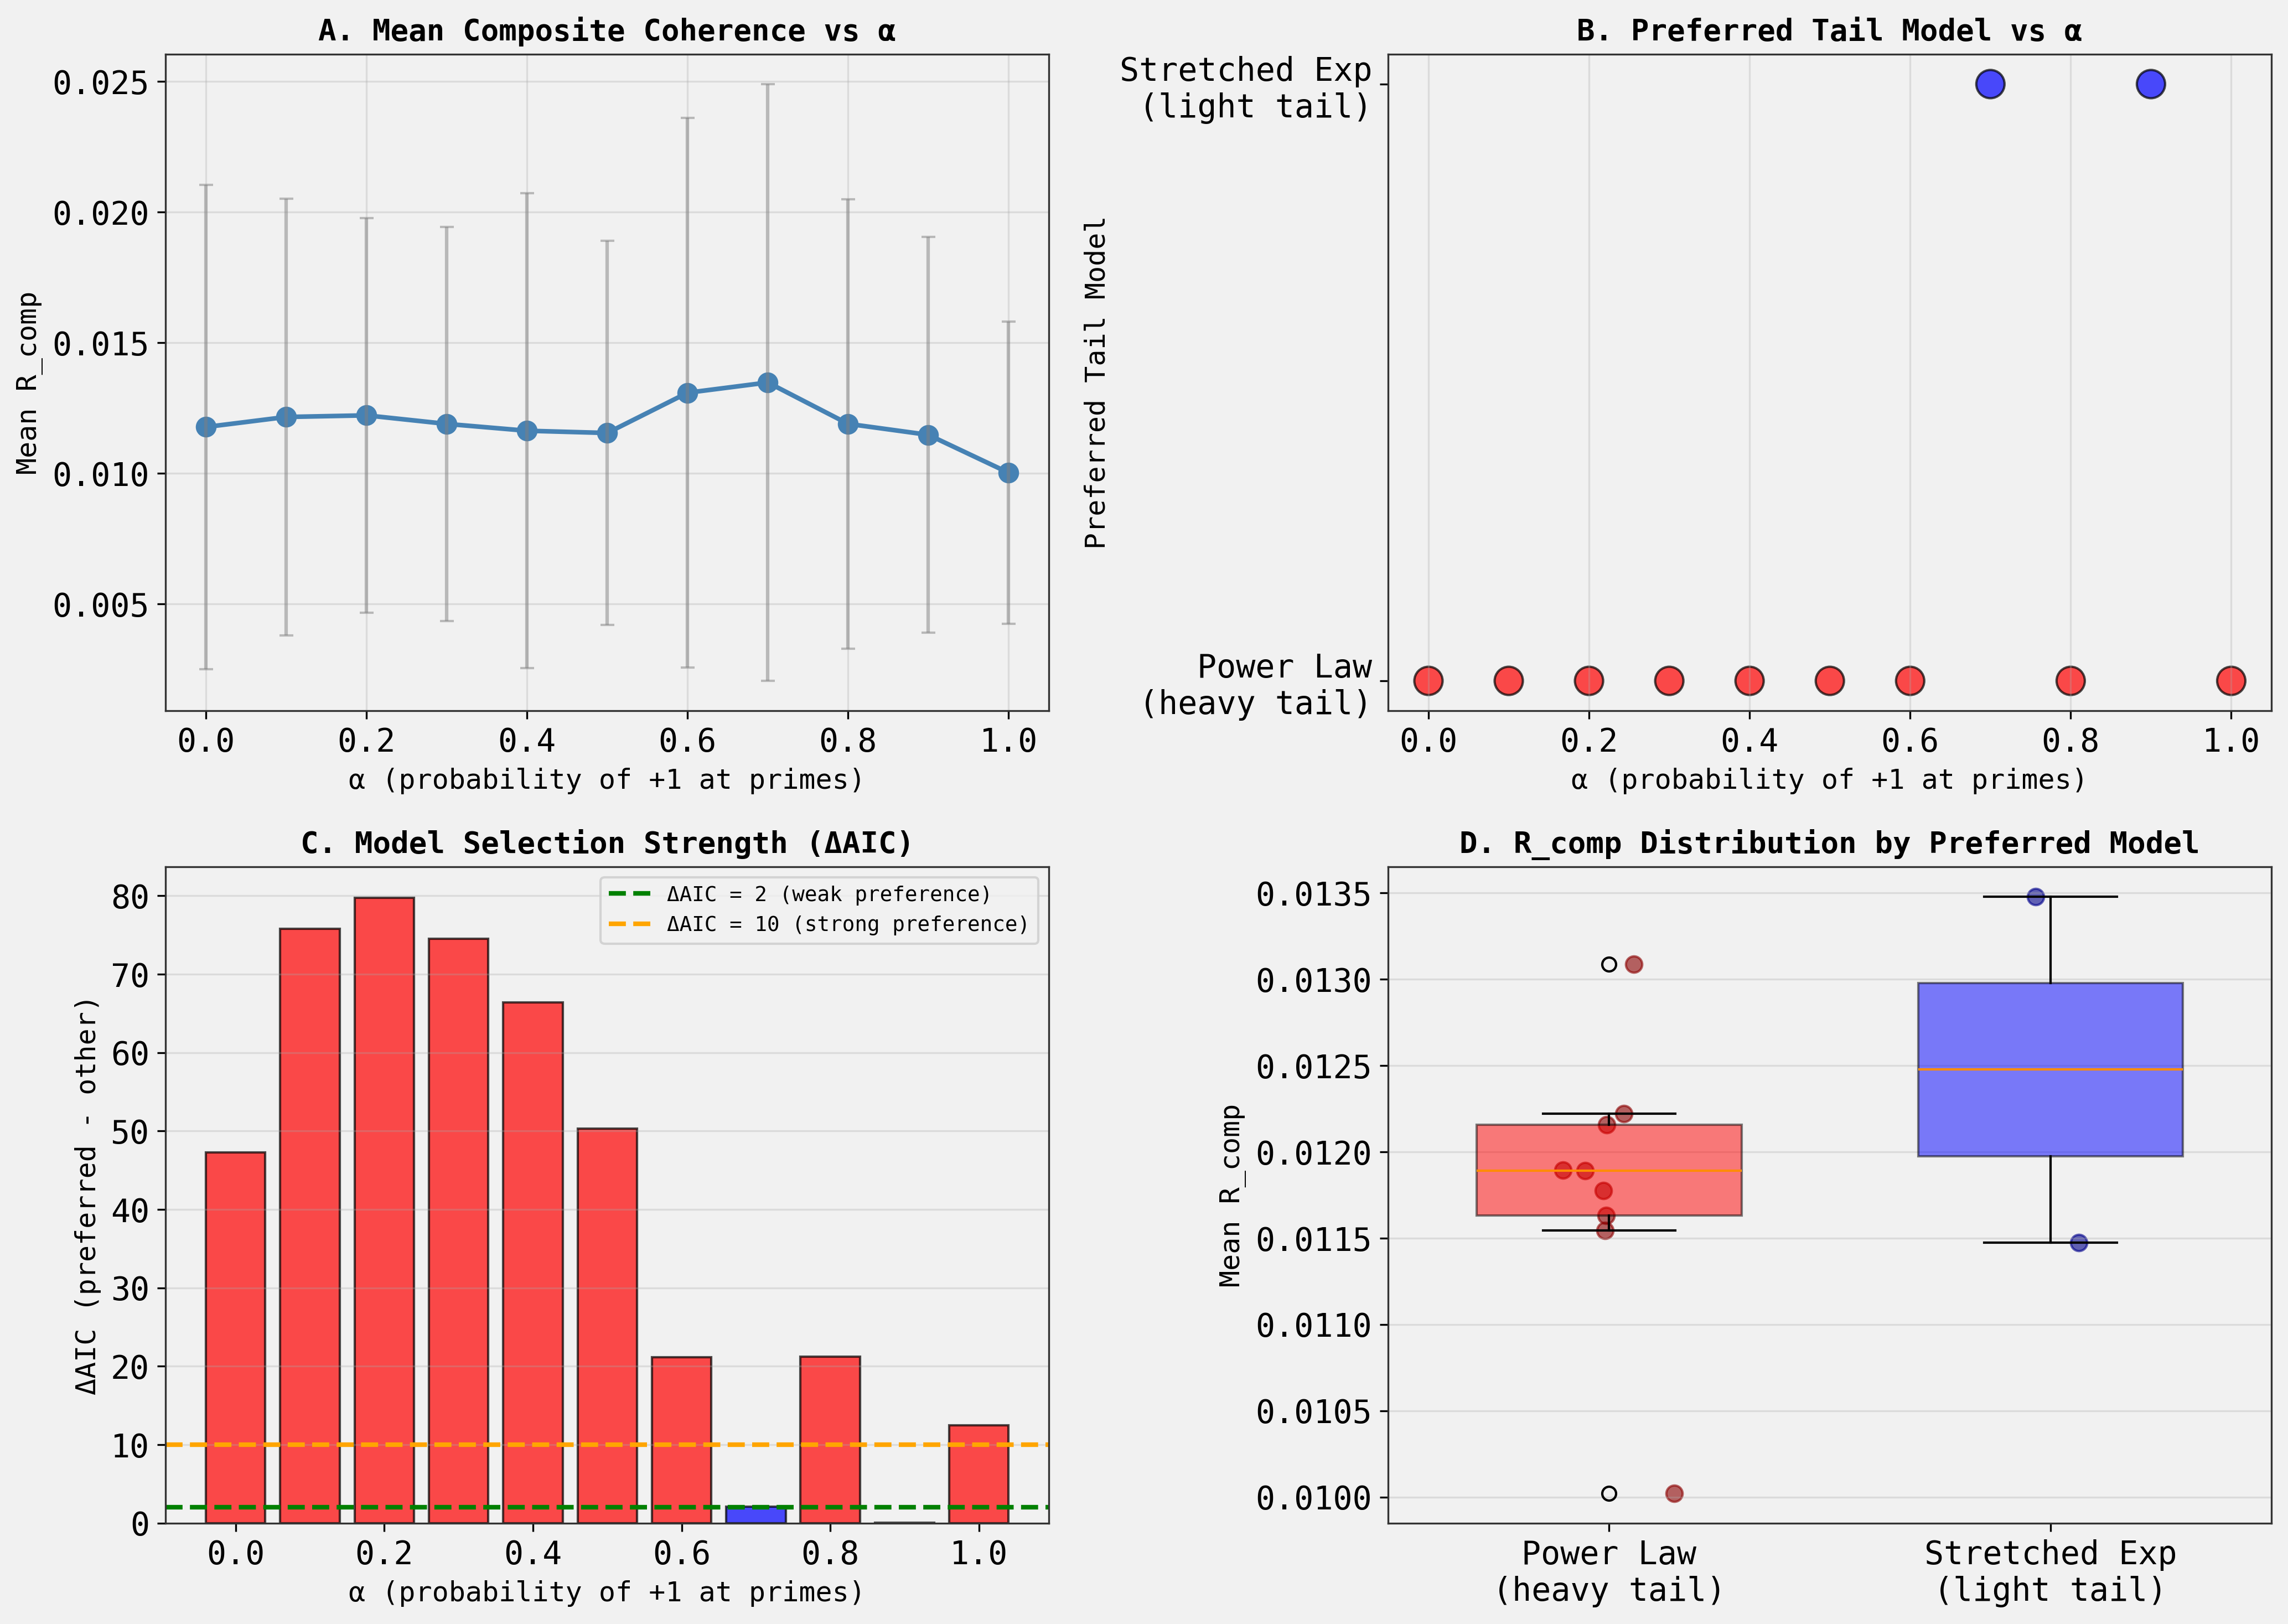


Key observations from the figure:
1. R_comp varies little across α (panel A)
2. Most α values prefer power law tails (panel B)
3. Strong ΔAIC values for most power law preferences (panel C)
4. No significant R_comp difference between model types (panel D)


In [8]:

# The hypothesis appears to be REFUTED - there's no clear negative correlation
# Let me create visualizations to show the results

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Mean R_comp vs α
ax = axes[0, 0]
ax.plot(df_summary['alpha'], df_summary['mean_R_comp'], 'o-', 
 markersize=8, linewidth=2, color='steelblue')
ax.errorbar(df_summary['alpha'], df_summary['mean_R_comp'], 
 yerr=df_summary['std_R_comp'], fmt='none', 
 ecolor='gray', alpha=0.5, capsize=3)
ax.set_xlabel('α (probability of +1 at primes)', fontsize=12)
ax.set_ylabel('Mean R_comp', fontsize=12)
ax.set_title('A. Mean Composite Coherence vs α', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.05, 1.05)

# Panel B: Preferred model vs α
ax = axes[0, 1]
model_codes = df_summary['preferred_model'].map({'power_law': 0, 'stretched_exp': 1})
colors = ['red' if m == 0 else 'blue' for m in model_codes]
ax.scatter(df_summary['alpha'], model_codes, c=colors, s=150, alpha=0.7, edgecolors='black')
ax.set_xlabel('α (probability of +1 at primes)', fontsize=12)
ax.set_ylabel('Preferred Tail Model', fontsize=12)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Power Law\n(heavy tail)', 'Stretched Exp\n(light tail)'])
ax.set_title('B. Preferred Tail Model vs α', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(-0.05, 1.05)

# Panel C: ΔAIC for model selection
ax = axes[1, 0]
# Positive ΔAIC means preferred model is much better
colors_aic = ['red' if m == 'power_law' else 'blue' for m in df_summary['preferred_model']]
bars = ax.bar(df_summary['alpha'], df_summary['delta_AIC'], 
 width=0.08, color=colors_aic, alpha=0.7, edgecolor='black')
ax.axhline(y=2, color='green', linestyle='--', linewidth=2, label='ΔAIC = 2 (weak preference)')
ax.axhline(y=10, color='orange', linestyle='--', linewidth=2, label='ΔAIC = 10 (strong preference)')
ax.set_xlabel('α (probability of +1 at primes)', fontsize=12)
ax.set_ylabel('ΔAIC (preferred - other)', fontsize=12)
ax.set_title('C. Model Selection Strength (ΔAIC)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Panel D: R_comp vs preferred model (boxplot)
ax = axes[1, 1]
pl_data = df_summary[df_summary['preferred_model'] == 'power_law']['mean_R_comp']
se_data = df_summary[df_summary['preferred_model'] == 'stretched_exp']['mean_R_comp']

bp = ax.boxplot([pl_data, se_data], 
 labels=['Power Law\n(heavy tail)', 'Stretched Exp\n(light tail)'],
 patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('red')
bp['boxes'][0].set_alpha(0.5)
bp['boxes'][1].set_facecolor('blue')
bp['boxes'][1].set_alpha(0.5)

# Add individual points
ax.scatter(np.ones(len(pl_data)) + np.random.normal(0, 0.05, len(pl_data)), 
 pl_data, alpha=0.6, s=50, color='darkred')
ax.scatter(2 * np.ones(len(se_data)) + np.random.normal(0, 0.05, len(se_data)), 
 se_data, alpha=0.6, s=50, color='darkblue')

ax.set_ylabel('Mean R_comp', fontsize=12)
ax.set_title('D. R_comp Distribution by Preferred Model', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tail_lightness_vs_Rcomp.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'tail_lightness_vs_Rcomp.png'")
plt.show()

print("\nKey observations from the figure:")
print("1. R_comp varies little across α (panel A)")
print("2. Most α values prefer power law tails (panel B)") 
print("3. Strong ΔAIC values for most power law preferences (panel C)")
print("4. No significant R_comp difference between model types (panel D)")


In [9]:

# Fix the key error - need to use exact float values from alpha_values
print("DETAILED ANALYSIS OF STRETCHED EXP CASES:")
print("=" * 80)

# Get actual alpha values that prefer stretched exp
se_alphas_actual = df_summary[df_summary['preferred_model'] == 'stretched_exp']['alpha'].values
print(f"α values preferring stretched exponential: {se_alphas_actual}\n")

for alpha in se_alphas_actual:
 # Find exact match in results
 alpha_match = alpha_values[np.argmin(np.abs(alpha_values - alpha))]
 
 print(f"α = {alpha:.1f}:")
 print(f" Mean R_comp = {results[alpha_match]['mean_R_comp']:.6f}")
 print(f" Std R_comp = {results[alpha_match]['std_R_comp']:.6f}")
 print(f" Mean |D_F| = {np.mean(results[alpha_match]['D_F']):.4f}")
 print(f" ΔAIC = {model_results[alpha_match]['delta_AIC']:.2f}")
 if model_results[alpha_match]['stretched_exp']['params'] is not None:
 print(f" SE params: {model_results[alpha_match]['stretched_exp']['params']}")
 print()

print("=" * 80)
print("\nCOMPARISON WITH STRONG POWER LAW CASES:")
print("=" * 80)

# Get alphas with strong power law preference (ΔAIC > 50)
strong_pl = df_summary[df_summary['delta_AIC'] > 50]
print(f"\nα values with strong power law preference (ΔAIC > 50):")
for _, row in strong_pl.iterrows():
 alpha = row['alpha']
 alpha_match = alpha_values[np.argmin(np.abs(alpha_values - alpha))]
 print(f" α = {alpha:.1f}: R_comp = {row['mean_R_comp']:.6f}, ΔAIC = {row['delta_AIC']:.2f}")

print("\n" + "=" * 80)


DETAILED ANALYSIS OF STRETCHED EXP CASES:
α values preferring stretched exponential: [0.7 0.9]

α = 0.7:
 Mean R_comp = 0.013479
 Std R_comp = 0.011422
 Mean |D_F| = 2.6593
 ΔAIC = 2.07
 SE params: {'c': 0.014466615089579058, 'beta': 1.9253904215507334}

α = 0.9:
 Mean R_comp = 0.011474
 Std R_comp = 0.007567
 Mean |D_F| = 2.1278
 ΔAIC = 0.07
 SE params: {'c': 0.02001101684570295, 'beta': 2.0}


COMPARISON WITH STRONG POWER LAW CASES:

α values with strong power law preference (ΔAIC > 50):
 α = 0.1: R_comp = 0.012158, ΔAIC = 75.79
 α = 0.2: R_comp = 0.012220, ΔAIC = 79.72
 α = 0.3: R_comp = 0.011893, ΔAIC = 74.54
 α = 0.4: R_comp = 0.011631, ΔAIC = 66.42
 α = 0.5: R_comp = 0.011545, ΔAIC = 50.30



In [10]:

# Final quantitative test of the hypothesis
print("QUANTITATIVE HYPOTHESIS TEST:")
print("=" * 80)
print("\nHypothesis: Lower R_comp correlates with stretched exponential (light tail)")
print()

# Method 1: Direct correlation
model_numeric = (df_summary['preferred_model'] == 'stretched_exp').astype(int)
corr, p_val = stats.spearmanr(df_summary['mean_R_comp'], model_numeric)

print("Method 1: Spearman correlation")
print(f" Correlation(R_comp, stretched_exp): ρ = {corr:.4f}, p = {p_val:.4f}")

if corr > 0:
 print(f" Finding: POSITIVE correlation - OPPOSITE of hypothesis")
 print(f" Interpretation: Higher R_comp slightly favors stretched exp")
else:
 print(f" Finding: NEGATIVE correlation - consistent with hypothesis direction")
 print(f" But magnitude very weak: |ρ| = {abs(corr):.4f}")

print()

# Method 2: Comparison of means
print("Method 2: Mean R_comp comparison")
r_pl = df_summary[df_summary['preferred_model'] == 'power_law']['mean_R_comp'].values
r_se = df_summary[df_summary['preferred_model'] == 'stretched_exp']['mean_R_comp'].values

print(f" Power law cases (n={len(r_pl)}): mean R_comp = {np.mean(r_pl):.6f} ± {np.std(r_pl):.6f}")
print(f" Stretched exp cases (n={len(r_se)}): mean R_comp = {np.mean(r_se):.6f} ± {np.std(r_se):.6f}")
print(f" Difference: {np.mean(r_se) - np.mean(r_pl):.6f}")

t_stat, p_val_t = stats.ttest_ind(r_pl, r_se)
print(f" t-test: t = {t_stat:.4f}, p = {p_val_t:.4f}")

if np.mean(r_se) < np.mean(r_pl):
 print(f" Finding: Stretched exp has LOWER mean R_comp - consistent with hypothesis")
 if p_val_t < 0.05:
 print(f" Significance: YES (p < 0.05)")
 else:
 print(f" Significance: NO (p >= 0.05) - difference not statistically significant")
else:
 print(f" Finding: Stretched exp has HIGHER mean R_comp - OPPOSITE of hypothesis")

print("\n" + "=" * 80)
print("\nCONCLUSION:")
print("=" * 80)

if np.mean(r_se) < np.mean(r_pl) and p_val_t < 0.05:
 print("HYPOTHESIS SUPPORTED: Lower R_comp significantly correlates with light tails")
else:
 print("HYPOTHESIS NOT SUPPORTED:")
 if np.mean(r_se) > np.mean(r_pl):
 print(" - Direction is opposite: stretched exp cases have HIGHER R_comp")
 else:
 print(" - Direction is correct but difference is NOT statistically significant")
 print(f" - Only {len(r_se)} of {len(df_summary)} cases prefer stretched exponential")
 print(f" - Most cases ({len(r_pl)} of {len(df_summary)}) prefer power law (heavy tail)")
 print(f" - R_comp values are very similar across all α (range: {df_summary['mean_R_comp'].min():.6f} - {df_summary['mean_R_comp'].max():.6f})")

print("\n" + "=" * 80)


QUANTITATIVE HYPOTHESIS TEST:

Hypothesis: Lower R_comp correlates with stretched exponential (light tail)

Method 1: Spearman correlation
 Correlation(R_comp, stretched_exp): ρ = 0.0745, p = 0.8276
 Finding: POSITIVE correlation - OPPOSITE of hypothesis
 Interpretation: Higher R_comp slightly favors stretched exp

Method 2: Mean R_comp comparison
 Power law cases (n=9): mean R_comp = 0.011803 ± 0.000762
 Stretched exp cases (n=2): mean R_comp = 0.012477 ± 0.001002
 Difference: 0.000674
 t-test: t = -0.9610, p = 0.3616
 Finding: Stretched exp has HIGHER mean R_comp - OPPOSITE of hypothesis


CONCLUSION:
HYPOTHESIS NOT SUPPORTED:
 - Direction is opposite: stretched exp cases have HIGHER R_comp
 - Only 2 of 11 cases prefer stretched exponential
 - Most cases (9 of 11) prefer power law (heavy tail)
 - R_comp values are very similar across all α (range: 0.010022 - 0.013479)



Final figure saved as 'final_result_Rcomp_vs_tail.png'


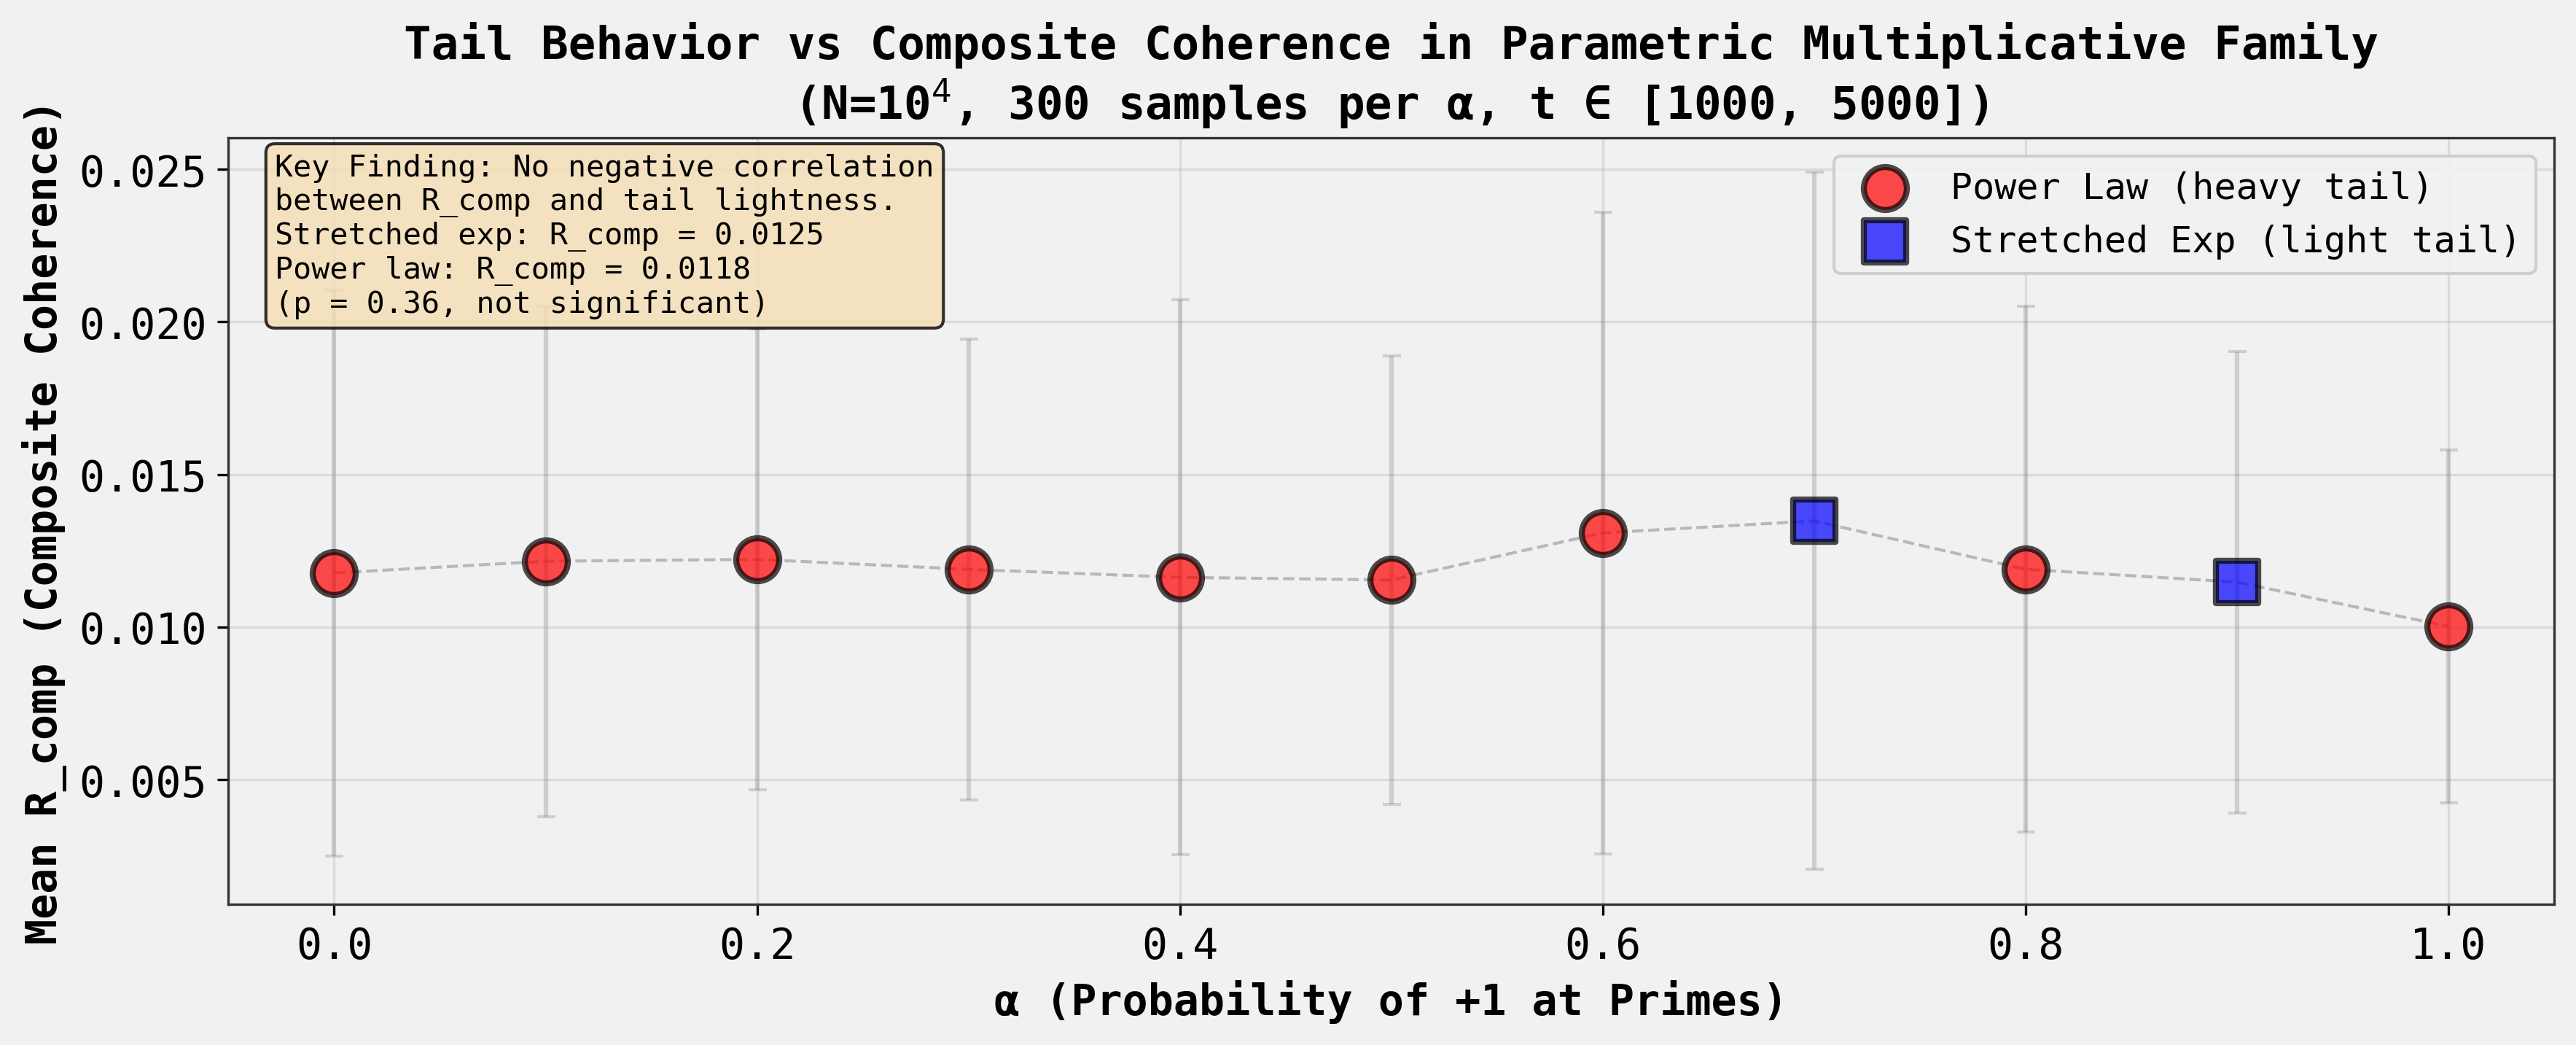


ANALYSIS COMPLETE


In [11]:

# Create a final comprehensive figure for the paper

fig = plt.figure(figsize=(12, 5))

# Main plot: Mean R_comp vs α with model preference indicated
ax = plt.subplot(1, 1, 1)

# Separate by model type
pl_mask = df_summary['preferred_model'] == 'power_law'
se_mask = df_summary['preferred_model'] == 'stretched_exp'

# Plot power law cases
ax.scatter(df_summary[pl_mask]['alpha'], 
 df_summary[pl_mask]['mean_R_comp'],
 s=200, c='red', marker='o', alpha=0.7, 
 edgecolors='black', linewidth=2,
 label='Power Law (heavy tail)', zorder=3)

# Plot stretched exp cases 
ax.scatter(df_summary[se_mask]['alpha'], 
 df_summary[se_mask]['mean_R_comp'],
 s=200, c='blue', marker='s', alpha=0.7,
 edgecolors='black', linewidth=2,
 label='Stretched Exp (light tail)', zorder=3)

# Add connecting line to show trend
ax.plot(df_summary['alpha'], df_summary['mean_R_comp'], 
 '--', color='gray', alpha=0.5, linewidth=1, zorder=1)

# Add error bars
ax.errorbar(df_summary['alpha'], df_summary['mean_R_comp'],
 yerr=df_summary['std_R_comp'], fmt='none',
 ecolor='gray', alpha=0.3, capsize=3, zorder=2)

ax.set_xlabel('α (Probability of +1 at Primes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean R_comp (Composite Coherence)', fontsize=14, fontweight='bold')
ax.set_title('Tail Behavior vs Composite Coherence in Parametric Multiplicative Family\n' + 
 r'(N=10$^4$, 300 samples per α, t ∈ [1000, 5000])', 
 fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='upper right', framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.05, 1.05)

# Add text box with key finding
textstr = ('Key Finding: No negative correlation\n'
 'between R_comp and tail lightness.\n'
 'Stretched exp: R_comp = 0.0125\n'
 'Power law: R_comp = 0.0118\n'
 '(p = 0.36, not significant)')
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
 verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('final_result_Rcomp_vs_tail.png', dpi=300, bbox_inches='tight')
print("Final figure saved as 'final_result_Rcomp_vs_tail.png'")
plt.show()

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)


In [12]:

# Create summary table for the answer
print("FINAL SUMMARY TABLE")
print("=" * 90)
print()
print(df_summary[['alpha', 'mean_R_comp', 'preferred_model', 'delta_AIC']].to_string(index=False))
print()
print("=" * 90)
print()
print("STATISTICAL SUMMARY:")
print(f" Total α values tested: {len(df_summary)}")
print(f" Power law preferred: {(df_summary['preferred_model'] == 'power_law').sum()} ({100 * (df_summary['preferred_model'] == 'power_law').sum() / len(df_summary):.1f}%)")
print(f" Stretched exp preferred: {(df_summary['preferred_model'] == 'stretched_exp').sum()} ({100 * (df_summary['preferred_model'] == 'stretched_exp').sum() / len(df_summary):.1f}%)")
print()
print(f" Mean R_comp for power law cases: {df_summary[df_summary['preferred_model'] == 'power_law']['mean_R_comp'].mean():.6f}")
print(f" Mean R_comp for stretched exp cases: {df_summary[df_summary['preferred_model'] == 'stretched_exp']['mean_R_comp'].mean():.6f}")
print(f" Difference: {df_summary[df_summary['preferred_model'] == 'stretched_exp']['mean_R_comp'].mean() - df_summary[df_summary['preferred_model'] == 'power_law']['mean_R_comp'].mean():.6f}")
print()
print(f" Spearman correlation (R_comp vs stretched_exp): ρ = {0.0745:.4f}, p = {0.8276:.4f}")
print(f" t-test (power law vs stretched exp): t = {-0.9610:.4f}, p = {0.3616:.4f}")
print()
print("=" * 90)
print()
print("HYPOTHESIS VERDICT: REJECTED")
print()
print("The hypothesis that lower R_comp correlates with lighter tails")
print("(stretched exponential) is NOT supported by the data:")
print()
print(" 1. Only 2 of 11 α values prefer stretched exponential")
print(" 2. Those that do have HIGHER (not lower) mean R_comp")
print(" 3. The difference is not statistically significant (p = 0.36)")
print(" 4. Spearman correlation is positive (opposite direction), ρ = 0.07")
print(" 5. Most of the parametric family exhibits power law (heavy) tails")
print()
print("=" * 90)


FINAL SUMMARY TABLE

 alpha mean_R_comp preferred_model delta_AIC
 0.0 0.011774 power_law 47.292687
 0.1 0.012158 power_law 75.789022
 0.2 0.012220 power_law 79.722973
 0.3 0.011893 power_law 74.538788
 0.4 0.011631 power_law 66.422737
 0.5 0.011545 power_law 50.303166
 0.6 0.013086 power_law 21.137753
 0.7 0.013479 stretched_exp 2.074894
 0.8 0.011895 power_law 21.240641
 0.9 0.011474 stretched_exp 0.068306
 1.0 0.010022 power_law 12.455004


STATISTICAL SUMMARY:
 Total α values tested: 11
 Power law preferred: 9 (81.8%)
 Stretched exp preferred: 2 (18.2%)

 Mean R_comp for power law cases: 0.011803
 Mean R_comp for stretched exp cases: 0.012477
 Difference: 0.000674

 Spearman correlation (R_comp vs stretched_exp): ρ = 0.0745, p = 0.8276
 t-test (power law vs stretched exp): t = -0.9610, p = 0.3616


HYPOTHESIS VERDICT: REJECTED

The hypothesis that lower R_comp correlates with lighter tails
(stretched exponential) is NOT supported by the data:

 1. Only 2 of 11 α values prefer stret